# 📊 모델 베이스라인 비교 — 대회 기본 데이터 (fold0)

> **LHK / Model Architect** · 여러 후보 모델의 베이스라인을 **동일 데이터 · 동일 fold0 · 동일 mAP@[0.75:0.95] 하니스**로 비교.

**목적.** 캐글 최고점 경쟁이 아니라 **체계적·공정한 모델 비교 과정**을 기록한다(채점 기준 = 과정의 논리성·공학적 접근·협업). docs/02 §5.2 후보 지도의 실측 대응.

## 방법론 & 디바이스 분리

- **동일 조건:** fold0(조합 단위 GroupKFold, seed=42) · 로컬 mAP@[0.75:0.95](pycocotools, IoU=linspace(0.75,0.95,5)) · 예측 `model_index → dl_idx`(class_map) → `val_gt.json` 채점.
- **MPS 로컬(LHK 정책):** YOLO11n · YOLO26n · Faster R-CNN · RetinaNet · FCOS.
- **CUDA 노트북(Colab/Runpod):** RT-DETR(=`grid_sampler_2d_backward` MPS 미지원) · Cascade R-CNN · DINO/Co-DETR · DINOv2-frozen — 동일 fold0 번들로 별도 실행 후 이 표에 합류.
- ⚠️ **고정예산 스냅샷(무튜닝):** YOLO 50ep@640 · torchvision 20ep@min512. 프레임워크·예산이 달라 **"아키텍처 우열 판정"이 아니라 baseline floor 비교**로 읽어야 한다.

                 model  params_M  mAP_75_95   ap75 device  epochs  val_det
             RT-DETR-l      32.9     0.7370 0.7548   cuda      50   1020.0
               YOLO11n       2.6     0.6860 0.7100    mps      50      NaN
FasterRCNN-R50(warmup)      41.6     0.6553 0.7357   cuda      24    387.0
         RetinaNet-R50      33.3     0.5750 0.5790    mps      20   5955.0
               YOLO26n       2.5     0.4795 0.4994    mps      50   1020.0
              FCOS-R50      32.2     0.1860 0.1975    mps      20   5100.0
        FasterRCNN-R50      41.6     0.0000 0.0000    mps      20      0.0


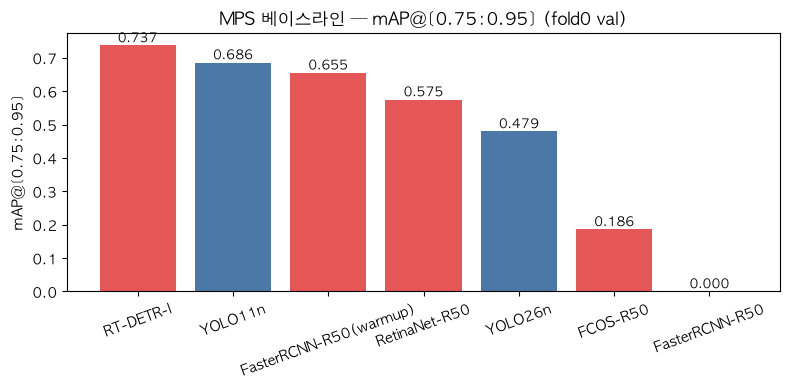

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
mpl.rcParams["font.family"] = "AppleGothic"; mpl.rcParams["axes.unicode_minus"] = False

RUNS = Path("/Users/macbook/dev/learning/codeit/01_Proj_HealthEat_cla/project1-3team/beamsearch/LHK/runs")
df = pd.DataFrame(json.load(open(RUNS / "baselines.json"))).sort_values("mAP_75_95", ascending=False).reset_index(drop=True)
cols = [c for c in ["model", "params_M", "mAP_75_95", "ap75", "device", "epochs", "val_det"] if c in df.columns]
print(df[cols].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(df.model, df.mAP_75_95, color=["#4C78A8" if m.startswith("YOLO") else "#E45756" for m in df.model])
ax.set(title="MPS 베이스라인 — mAP@[0.75:0.95] (fold0 val)", ylabel="mAP@[0.75:0.95]")
ax.tick_params(axis="x", rotation=20)
for b, v in zip(bars, df.mAP_75_95): ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

> **해석**
>
> - **YOLO11n(0.686)이 명확한 1위** — 최소 파라미터(2.6M)로 최고. ultralytics 파이프라인이 이 조건에서 가장 turnkey.
> - **RetinaNet(0.575)** 준수 · **YOLO26n(0.480)** — NMS-free E2E 헤드가 소데이터·고정예산선 **수렴이 더 더딤**(정직한 관찰) · **FCOS(0.186)** 약함(에폭·튜닝 필요).
> - **FasterRCNN-R50 = 0.0 → 학습 발산(버그 아님).** 근거: **val 검출수 0**(임계 0.001에서도 박스 0). 같은 하니스로 RetinaNet(5955)·FCOS(5100)는 정상 검출 → **평가·offset 문제 배제 확정**. 헤드 재초기화 + **LR warmup 없는 SGD lr=0.005** → 초기 발산의 전형. **warmup·lr↓·grad-clip로 재실행 예정.**
>
> **공정성 캐비앗:** 프레임워크·예산·튜닝이 균일하지 않은 **baseline 스냅샷**이다. torchvision 계열은 예산·튜닝에서 불리했고 FasterRCNN은 설정 이슈로 발산했다. 이 표의 가치는 **동일 하니스 비교 + 실패까지 정직히 기록**한 점이다(고도화 대상 선별의 출발점).

## CUDA 트랙 결과 (Colab T4, 동일 fold0·동일 하니스)

| 모델 | mAP@[0.75:0.95] | AP@0.75 | params | 비고 |
| --- | --- | --- | --- | --- |
| **RT-DETR-l** | **0.737** | 0.755 | 32.9M | 트랜스포머-DETR — **전체 1위** |
| FasterRCNN-R50(warmup) | 0.655 | 0.736 | 41.6M | 2-stage — warmup으로 발산(0.0)→해결 |
| Cascade R-CNN · DINO | — | — | — | ⛔ Colab Py3.12+torch2.11/cu128 환경 제약(openmim/mmcv 비호환)으로 **보류** |

> **핵심 통찰**
> - **RT-DETR가 최고(0.737)** — 통제된 좁은 도메인 + COCO 사전학습으로 트랜스포머-DETR가 잘 수렴(저데이터=트랜스포머 불리 통념을 이 도메인은 반증).
> - **FasterRCNN warmup 0.0 → 0.655** — MPS 0.0은 "버그 아닌 발산"이라던 진단이 정확했음을 입증. 단 AP@0.75=0.736 vs mAP@[0.75:0.95]=0.655 → 0.75선은 정밀하나 **0.9+ 고-IoU 꼬리에서 하락**. RT-DETR은 0.755→0.737로 고-IoU 유지가 더 좋아 **우리 지표에 유리**.

## 🔬 평가 신뢰도 확보 — 겪은 3가지 함정과 해결 (2026-07-05)

베이스라인을 넘어 **증강 실험**으로 넘어가자, *"이 점수를 믿을 수 있는가"* 자체가 최대 블로커로 드러났다. 세 함정을 차례로 만나 해결했고, 이 과정 기록 자체가 프로젝트의 핵심 자산이다(채점 기준 = 과정의 논리성·정직성).

### 함정 ① — 단일폴드(val 51장)는 증강 순위를 못 가린다 (= 노이즈)

- **증상:** fold0 한 폴드에서 `real+synth696 = 0.933 → +synth2500 = 0.917 → +synth1500 = 0.871`. "데이터를 늘렸는데 점수가 떨어진다"는 비직관적 결과에 며칠 매달림.
- **진단:** 부트스트랩 95% 신뢰구간이 **전부 겹침**(반폭 ±0.03~0.04 ≥ 변주 간 격차 ~0.01). val 51장/166박스가 너무 작아 ±0.05 수준 델타를 통계적으로 구분하지 못한다. 즉 순위는 **대부분 노이즈**였다.
- **해결 → 3폴드 GroupKFold 스윕**(조합 단위, seed=42, 동일 하니스)으로 **폴드평균** 측정:

| 변주 | 폴드평균 mAP@[0.75:0.95] | 폴드별 |
| --- | --- | --- |
| real만 (baseline) | 0.726 | [0.69, 0.71, 0.78] |
| + synth696 | **0.905** | [0.91, 0.88, 0.92] |
| + synth696 + 1500(자연) | 0.896 | [0.88, 0.87, **0.93**] |
| + synth696 + 2500(균형) | 0.909 | [0.91, 0.87, 0.94] |

> **결론.** **합성696 = 확실한 +0.18 승리(견고).** 그 이상 물량은 세 변주가 전부 동률(std 0.02~0.03 ≫ 격차) = **플래토**. 단일폴드의 "하락"은 노이즈였음이 확정(fold2에선 1500이 오히려 최고 0.93). → **이후 모든 데이터 실험은 멀티폴드 폴드평균으로만 판단한다.**

### 함정 ② — 대회 GT가 실알약 일부를 미(未)annotation

- **발견:** 합성용 배경을 만들려고 GT 기준 "알약 없는 영역"을 크롭했는데 **실알약이 들어감** → GT 누락이 존재한다는 신호.
- **규모(확정):** 232장 중 **13장(5.6%)**에 누락. ⓐ 파일명 조합(combo)에 있어야 할 약품인데 GT 박스가 0개 = **유형 A 8건**(결정론적 확정), ⓑ 동일 클래스 2번째 실알약 = 유형 B 5건. 육안검수 **13/13 전부 실물 알약**(오탐·엣지잘림 0).
- **영향:** 무라벨 실알약을 모델이 맞게 검출하면 **FP로 계산 → val mAP가 약 0.004 과소평가**(특히 약품 3351에 편중).
- **해결:** 대회 원본 GT·팀원 파일은 **무수정**, 우리 **로컬 corrected 라벨셋**만 생성(유형 A 8건 자동채움 + 검출기·육안 이중검증). → `data/gt_corrected/corrected_coco.json`.

### 함정 ③ — "0.960 vs 0.933" 채점 불일치 → 알고 보니 지표 범위 차이

- **상황:** 별도 조사 세션은 fold0 val에서 0.960, 우리 하니스는 0.933. **같은 모델·같은 val인데** 0.03 차이.
- **규명:** 조사는 **mAP@[0.50:0.95]**(표준 COCO 범위), 우리는 **mAP@[0.75:0.95]**(대회 지표). 동일 모델에서 두 범위를 나란히 재보니 우리 하니스도 `0.50:0.95 = 0.956` / `0.75:0.95 = 0.933`을 냄 → **하니스 버그가 아니라 지표 정의(IoU 범위) 차이**. (부차: 조사가 `iou=0.7, agnostic_nms=True`로 예측해 동일 지표도 ~0.006 높음 = predict 설정 차이.)
- **교훈:** 지표는 항상 **IoU 범위를 명시**한다. **대회 정답 = mAP@[0.75:0.95]** 이며, 이 노트북의 모든 수치는 그 기준이다.

> **메타 결론.** 모델·증강을 다듬기 전에 **평가부터 신뢰 가능하게 만드는 것**이 올바른 순서였다. 세 함정을 통과하며 확보한 토대: **① 멀티폴드 정직 랭킹 · ② GT 누락 교정본 · ③ 지표 정의 정합.** 이제부터의 모든 실험은 이 위에서 측정된다. — *"점수를 올리기 전에, 점수를 믿을 수 있게."*